In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load generated file
df = pd.read_csv("mushroom_paths.csv")

# Basic info
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102713 entries, 0 to 102712
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   file_path     102713 non-null  object 
 1   depth         102713 non-null  int64  
 2   file_name     102713 non-null  object 
 3   file_ext      102713 non-null  object 
 4   width         102713 non-null  int64  
 5   height        102713 non-null  int64  
 6   aspect_ratio  102713 non-null  float64
 7   class         102713 non-null  object 
 8   species       102713 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 7.1+ MB


,file_path,depth,file_name,file_ext,width,height,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14...,3,14,png,512,512,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12...,3,12,png,512,512,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13...,3,13,png,512,512,1.0,conditionally_edible,horn_of_plenty


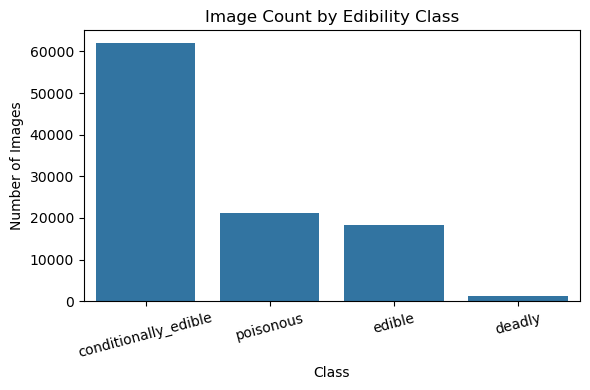

In [4]:
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Image Count by Edibility Class")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [8]:
class_counts = df["class"].value_counts()
class_props = df["class"].value_counts(normalize=True)

class_counts, class_props


(class
 conditionally_edible    61968
 poisonous               21138
 edible                  18417
 deadly                   1190
 Name: count, dtype: int64,
 class
 conditionally_edible    0.603312
 poisonous               0.205797
 edible                  0.179305
 deadly                  0.011586
 Name: proportion, dtype: float64)

In [6]:
df.shape


(102713, 9)

In [10]:
df["species"].nunique()


570

In [11]:
df["species"].value_counts().head(10)


species
Xanthoria parietina      5837
Fomes fomentarius        5254
Fomitopsis pinicola      5096
Amanita muscaria         4258
Lactarius                3126
Parmelia sulcata         2654
Laetiporus sulphureus    2302
Russula                  2296
Hypogymnia physodes      2166
Boletus                  2146
Name: count, dtype: int64

In [12]:
df[["width", "height"]].describe()


,width,height
count,102713.000000,102713.000000
mean,462.774741,429.986136
std,168.250166,122.454167
min,90.000000,90.000000
25%,375.000000,374.000000
50%,500.000000,500.000000
75%,500.000000,500.000000
max,1280.000000,1024.000000


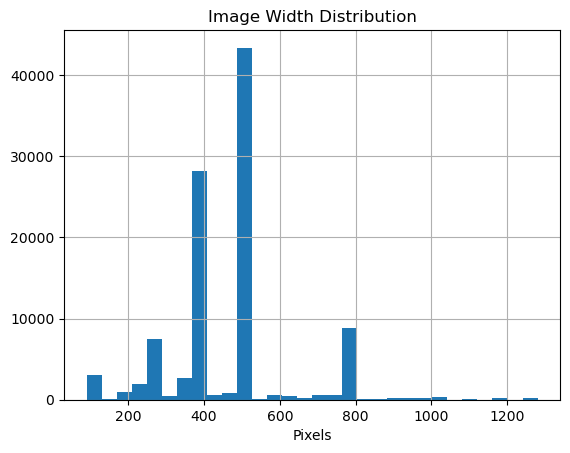

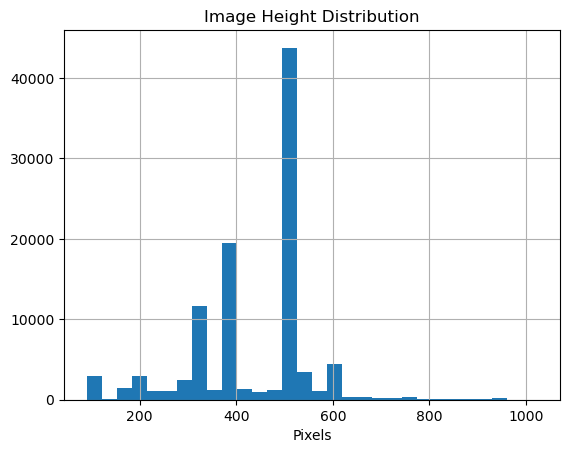

In [13]:
df["width"].hist(bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Pixels")
plt.show()

df["height"].hist(bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Pixels")
plt.show()


In [14]:
df["aspect_ratio"].describe()


count    102713.000000
mean          1.118032
std           0.352166
min           0.252000
25%           0.750000
50%           1.256281
75%           1.336898
max           4.385965
Name: aspect_ratio, dtype: float64

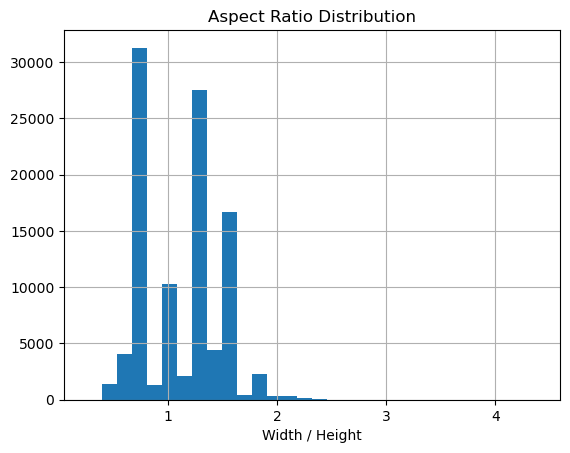

In [15]:
df["aspect_ratio"].hist(bins=30)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.show()


In [18]:
df["file_ext"].value_counts()


file_ext
jpg     45580
jpeg    45163
png     11959
JPG        11
Name: count, dtype: int64

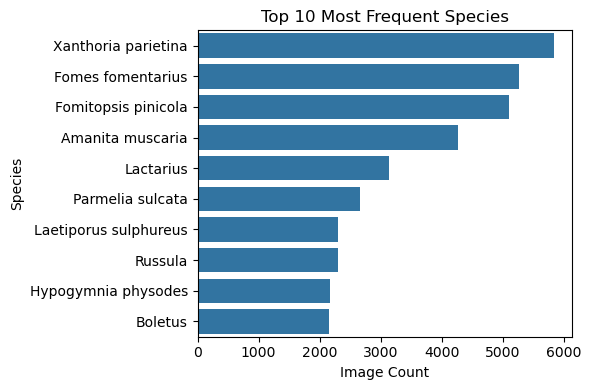

In [23]:
top_species = df['species'].value_counts().head(10)

plt.figure(figsize=(6,4))
sns.barplot(x=top_species.values, y=top_species.index)
plt.title("Top 10 Most Frequent Species")
plt.xlabel("Image Count")
plt.ylabel("Species")
plt.tight_layout()
plt.show()


In [25]:
# Duplicate file paths
df['file_path'].duplicated().sum()

# Zero-sized images (should be none)
df[(df['width'] == 0) | (df['height'] == 0)].shape[0]


0